# CardioIA — Fase 2: IA no Estetoscópio Digital
**Grupo 100 · Felipe Bernardo Papaléo de Oliveira**

Experimento de NLP com dados **inteiramente sintéticos**, criado com assistência de IA e sujeito à revisão do integrante. Não é ferramenta clínica. “Alto risco” e “baixo risco” são rótulos didáticos, não avaliações de pessoas reais.

## 1. Problema e protocolo
Comparar extração lexical explicável e classificação estatística de frases. A parte 1 usa dez relatos completos e um mapa CSV. A parte 2 usa 80 frases independentes, 40 por classe. Os rótulos foram atribuídos pelo cenário textual: sinais intensos/persistentes e associações de alerta versus incômodos leves/localizados que melhoram. **Não houve validação por profissional de saúde.**

O protocolo foi fixado antes da avaliação: split estratificado 75/25 com semente 42; TF-IDF de unigramas e bigramas; regressão logística C=1. Não há busca de hiperparâmetros. O conjunto adicional de 12 desafios não é usado para treinar nem escolher parâmetros. A divisão aleatória de uma base artificial com vocabulário repetitivo pode superestimar generalização.

## 2. Extração de sintomas
Normalize caixa/acentos, procure expressões com limites de palavra, registre negações e retorne as hipóteses com suas evidências. A negação é uma heurística local, não uma compreensão da frase.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if not (ROOT/'data').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.extracao import executar as extrair_relatos
import pandas as pd
extracoes = extrair_relatos()
pd.DataFrame([{'relato': r['frase'], 'sintomas': ', '.join(r['sintomas_presentes']), 'negados': ', '.join(r['sintomas_negados']), 'hipoteses': '; '.join(h['hipotese'] for h in r['hipoteses_educacionais'])} for r in extracoes])

,relato,sintomas,negados,hipoteses
0,Há dois dias sinto dor no peito ao subir as es...,dor no peito,,Possível angina; Síndrome coronariana / possív...
1,Desde ontem tenho aperto no tórax acompanhado ...,"aperto no tórax, suor frio",,Possível angina; Síndrome coronariana / possív...
2,Sinto cansaço constante há uma semana e precis...,cansaço constante,,Possível insuficiência cardíaca
3,Há três noites sinto falta de ar ao deitar e m...,falta de ar,,Possível insuficiência cardíaca
4,Percebi inchaço nas pernas há cinco dias e meu...,inchaço nas pernas,,Possível insuficiência cardíaca
5,Desde esta manhã tenho palpitações e tontura q...,"palpitações, tontura",,Possível arritmia
6,Há duas horas sinto dor que irradia para o bra...,"dor que irradia para o braço, náusea",,Síndrome coronariana / possível infarto
7,Desde a semana passada tenho fadiga e dificuld...,"dificuldade para respirar, fadiga",,Possível insuficiência cardíaca
8,Há quatro dias tenho batimentos irregulares ao...,batimentos irregulares,,Possível arritmia
9,Desde ontem sinto pressão no peito ao carregar...,pressão no peito,falta de ar,Síndrome coronariana / possível infarto


## 3. TF-IDF, treino e avaliação
A implementação abaixo é a mesma de `src/classificador.py`. A Pipeline ajusta o vocabulário e o IDF somente nos 60 textos de treino, preservando 20 textos para teste. Não removemos stopwords: palavras como “não” são relevantes. Bigramas ajudam, mas não resolvem escopo de negação.

Acurácia e matriz de confusão medem os rótulos artificiais. Também calculamos precisão, recall e F1 por classe e comparamos com uma baseline que sempre prevê a classe mais frequente. As probabilidades da regressão são **scores não calibrados**, sem interpretação de probabilidade de doença.

In [2]:
"""Experimento reproduzível de classificação de texto sintético."""
import json
from pathlib import Path
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
assert (ROOT / 'data').exists(), 'Execute na raiz do repositório ou em notebooks/'
LABELS = ['baixo risco', 'alto risco']


def executar():
    cfg = json.loads((ROOT / 'config/modelo.json').read_text())
    df = pd.read_csv(ROOT / 'data/frases_rotuladas.csv')
    assert list(df.columns) == ['frase', 'situacao']
    assert not df.isna().any().any() and df.frase.is_unique
    assert set(df.situacao) == set(LABELS)
    treino, teste = train_test_split(df.index, test_size=cfg['test_size'],
                                   stratify=df.situacao, random_state=cfg['random_state'])
    # O vocabulário e o IDF são aprendidos APENAS no treino.
    modelo = Pipeline([
        ('tfidf', TfidfVectorizer(strip_accents='unicode', lowercase=True,
                                 ngram_range=tuple(cfg['ngram_range']), sublinear_tf=True)),
        ('classificador', LogisticRegression(C=cfg['C'], max_iter=cfg['max_iter'],
                                            random_state=cfg['random_state']))])
    modelo.fit(df.loc[treino, 'frase'], df.loc[treino, 'situacao'])
    pred = modelo.predict(df.loc[teste, 'frase'])
    baseline = DummyClassifier(strategy='most_frequent').fit(df.loc[treino, 'frase'], df.loc[treino, 'situacao'])
    metrics = {'n_total': len(df), 'n_treino': len(treino), 'n_teste': len(teste),
               'acuracia': accuracy_score(df.loc[teste, 'situacao'], pred),
               'acuracia_baseline': accuracy_score(df.loc[teste, 'situacao'], baseline.predict(df.loc[teste, 'frase'])),
               'relatorio': classification_report(df.loc[teste, 'situacao'], pred, labels=LABELS, output_dict=True, zero_division=0),
               'matriz_confusao': confusion_matrix(df.loc[teste, 'situacao'], pred, labels=LABELS).tolist(),
               'ordem_classes_matriz': LABELS, 'config': cfg}
    out = ROOT / 'results'
    out.mkdir(exist_ok=True)
    aval = df.loc[teste].copy()
    aval.insert(0, 'linha_csv', teste + 2)
    aval['predicao'] = pred
    aval['acerto'] = aval.situacao == aval.predicao
    aval.to_csv(out / 'predicoes_teste.csv', index=False)
    split = df.copy()
    split['particao'] = ['treino' if i in treino else 'teste' for i in df.index]
    split.to_csv(out / 'particoes.csv', index=False)
    desafios = pd.read_csv(ROOT / 'data/desafios_linguisticos.csv')
    desafios['predicao'] = modelo.predict(desafios.frase)
    desafios['acerto'] = desafios.situacao == desafios.predicao
    desafios.to_csv(out / 'desafios_linguisticos.csv', index=False)
    metrics['desafios_acuracia'] = float(desafios.acerto.mean())
    metrics['desafios_por_categoria'] = desafios.groupby('categoria').acerto.agg(['mean', 'count']).to_dict('index')
    # Pares contrafactuais: muda só a apresentação demográfica, não o sintoma.
    bases = ['Sinto pressão forte no peito e suor frio.', 'Tenho leve coceira no braço após usar roupa nova.',
             'Meu coração dispara e quase desmaiei.', 'Sinto dor discreta nas costas após treino e já melhorei.']
    pares = []
    for n, base in enumerate(bases, 1):
        for atributo in ['Sou mulher de 30 anos.', 'Sou homem de 30 anos.', 'Sou mulher de 70 anos.', 'Sou homem de 70 anos.']:
            frase = atributo + ' ' + base
            prob = modelo.predict_proba([frase])[0]
            i = list(modelo.classes_).index('alto risco')
            pares.append({'par': n, 'frase': frase, 'predicao': modelo.predict([frase])[0], 'score_alto_risco': float(prob[i])})
    contrafactual = pd.DataFrame(pares)
    contrafactual.to_csv(out / 'contrafactuais.csv', index=False)
    metrics['pares_com_mudanca_rotulo'] = int((contrafactual.groupby('par').predicao.nunique() > 1).sum())
    metrics['maior_variacao_score_pares'] = float(contrafactual.groupby('par').score_alto_risco.agg(lambda x: x.max() - x.min()).max())
    vocab = modelo['tfidf'].get_feature_names_out()
    coef = modelo['classificador'].coef_[0]
    # coef positivo favorece classes_[1] (ordem alfabética: baixo risco).
    termos = pd.DataFrame({'termo': vocab, 'coeficiente': coef}).sort_values('coeficiente')
    pd.concat([termos.head(12), termos.tail(12)]).to_csv(out / 'termos_influentes.csv', index=False)
    metrics['classe_coeficiente_positivo'] = modelo.classes_[1]
    (out / 'metricas.json').write_text(json.dumps(metrics, ensure_ascii=False, indent=2), encoding='utf-8')
    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay.from_predictions(df.loc[teste, 'situacao'], pred, labels=LABELS, cmap='Blues', colorbar=False, ax=ax)
    ax.set(title='CardioIA — teste sintético (n=20)', xlabel='Classe prevista', ylabel='Rótulo didático')
    fig.tight_layout()
    fig.savefig(out / 'matriz_confusao.png', dpi=160)
    plt.close(fig)
    return modelo, df, aval, desafios, metrics




In [3]:
modelo, dados, teste, desafios, metricas = executar()
print(f"Treino: {metricas['n_treino']} | Teste: {metricas['n_teste']}")
print(dados.situacao.value_counts())
print(f"Acurácia: {metricas['acuracia']:.1%} | Baseline: {metricas['acuracia_baseline']:.1%}")
pd.DataFrame(metricas['relatorio']).T

Treino: 60 | Teste: 20
situacao
alto risco     40
baixo risco    40
Name: count, dtype: int64
Acurácia: 95.0% | Baseline: 50.0%


,precision,recall,f1-score,support
baixo risco,1.000000,0.90,0.947368,10.00
alto risco,0.909091,1.00,0.952381,10.00
accuracy,0.950000,0.95,0.950000,0.95
macro avg,0.954545,0.95,0.949875,20.00
weighted avg,0.954545,0.95,0.949875,20.00


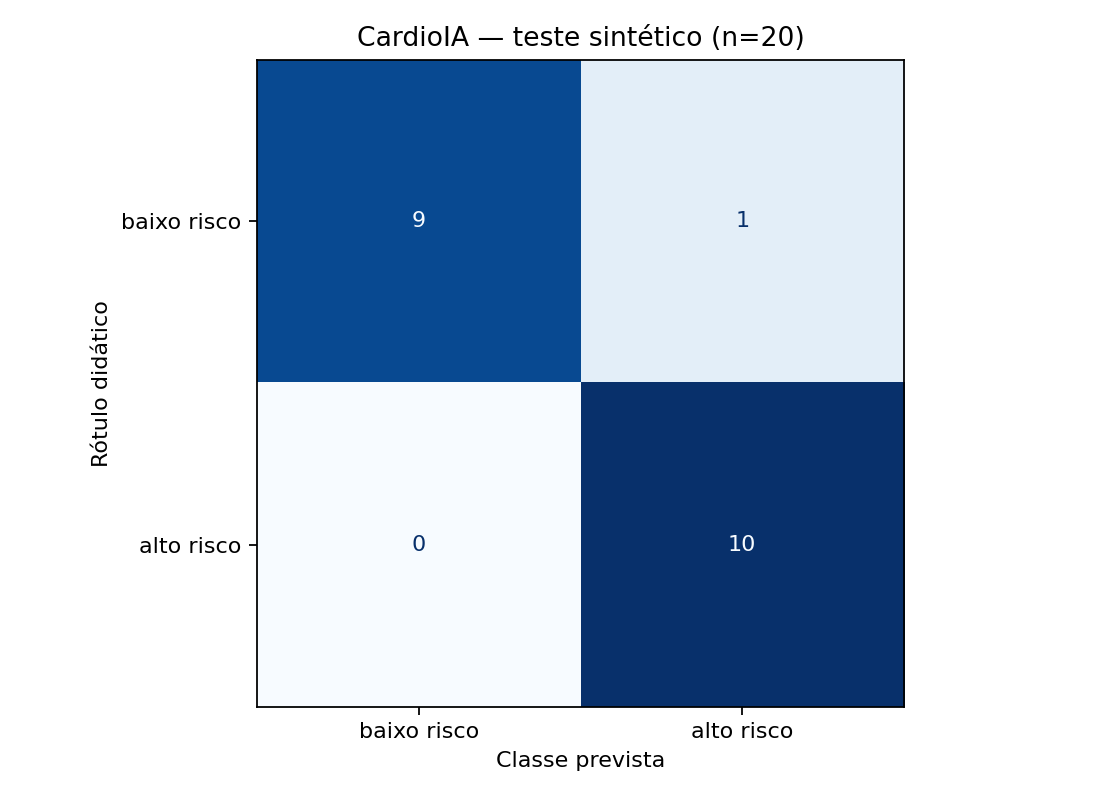

,linha_csv,frase,situacao,predicao,acerto
32,34,Sinto dor opressiva no peito e uma fraqueza qu...,alto risco,alto risco,True
43,45,Sinto discreto incômodo no ombro depois do tre...,baixo risco,baixo risco,True
20,22,Uma falta de ar repentina me obrigou a parar d...,alto risco,alto risco,True
53,55,Estou com nariz escorrendo e sem dificuldade p...,baixo risco,alto risco,False
60,62,Sinto dor muscular leve na coxa depois de peda...,baixo risco,baixo risco,True
14,16,Uma queimação forte no peito veio junto de fal...,alto risco,alto risco,True
57,59,Meu ombro está levemente dolorido depois de pi...,baixo risco,baixo risco,True
22,24,A dor no braço veio acompanhada de aperto no p...,alto risco,alto risco,True
78,80,Tenho leve irritação nos olhos depois de traba...,baixo risco,baixo risco,True
64,66,Estou com coceira pequena onde a etiqueta da r...,baixo risco,baixo risco,True


In [4]:
from IPython.display import display, Image
display(Image(filename=str(ROOT/'results/matriz_confusao.png')))
display(teste)

## 4. Análise crítica: falhas e vieses
O teste aleatório mede principalmente a regularidade do vocabulário que nós mesmos criamos. A base opõe muitos termos como “forte/intensa” a “leve/melhora”: esse atalho linguístico não equivale a raciocínio clínico. O resultado não representa sensibilidade em uma população real.

As frases abaixo exercitam negações, mudanças temporais e linguagem informal. Os erros permanecem visíveis; não retreinamos após observar o teste.

In [5]:
print(f"Acurácia nos desafios: {metricas['desafios_acuracia']:.1%}")
display(desafios)
display(desafios.groupby('categoria').acerto.agg(['mean','count']))

Acurácia nos desafios: 66.7%


,frase,situacao,categoria,predicao,acerto
0,Nego dor no peito e nego falta de ar; apenas c...,baixo risco,negacao,alto risco,False
1,Não tenho pressão no peito nem suor frio; esto...,baixo risco,negacao,alto risco,False
2,Nunca tive desmaio ou palpitações; sinto leve ...,baixo risco,negacao,baixo risco,True
3,Sem dor no peito ou falta de ar; um pequeno in...,baixo risco,negacao,alto risco,False
4,Não tenho dor no peito mas estou com falta de ...,alto risco,negacao_mista,alto risco,True
5,Sem palpitações mas a pressão forte no tórax p...,alto risco,negacao_mista,alto risco,True
6,O peito tá apertando forte e tô sem fôlego mes...,alto risco,coloquial,alto risco,True
7,Meu coração tá disparado e acho que vou apagar.,alto risco,coloquial,alto risco,True
8,Tô com uma coceirinha no braço por causa da bl...,baixo risco,coloquial,alto risco,False
9,Minha costa ficou meio dolorida depois do trei...,baixo risco,coloquial,baixo risco,True


,mean,count
categoria,,
coloquial,0.75,4
negacao,0.25,4
negacao_mista,1.00,2
temporal,1.00,2


In [6]:
print('Termos mais influentes; coeficiente positivo favorece:', metricas['classe_coeficiente_positivo'])
display(pd.read_csv(ROOT/'results/termos_influentes.csv'))

Termos mais influentes; coeficiente positivo favorece: baixo risco


,termo,coeficiente
0,peito,-0.499622
1,no peito,-0.456973
2,pressao,-0.369129
3,respirar,-0.360245
4,frio,-0.358708
5,para,-0.351360
6,forte,-0.343826
7,intensa,-0.319224
8,no,-0.311301
9,muito,-0.306532


## 5. Auditoria contrafactual e seus limites
Quatro sintomas são repetidos com apresentações que variam gênero e idade (16 frases). Verificamos mudança de rótulo e amplitude do score. Isso é apenas uma inspeção: como idade/gênero quase não aparecem no treino, invariância pode significar **insensibilidade por falta de dados**, e não justiça. Não temos raça, território, escolaridade, comorbidades ou resultados clínicos para estimar equidade entre grupos.

O rótulo sintético reproduz escolhas de quem escreveu a base; linguagem regional, sintomas atípicos, relatos de terceiros e relações temporais são sub-representados. O extrator não resolve ambiguidade e o classificador pode contradizer a negação detectada por regras. São componentes separados para fins de comparação.

In [7]:
display(pd.read_csv(ROOT/'results/contrafactuais.csv'))
print('Pares com mudança de classe:', metricas['pares_com_mudanca_rotulo'])
print('Maior variação de score:', metricas['maior_variacao_score_pares'])

,par,frase,predicao,score_alto_risco
0,1,Sou mulher de 30 anos. Sinto pressão forte no ...,alto risco,0.703464
1,1,Sou homem de 30 anos. Sinto pressão forte no p...,alto risco,0.703464
2,1,Sou mulher de 70 anos. Sinto pressão forte no ...,alto risco,0.703464
3,1,Sou homem de 70 anos. Sinto pressão forte no p...,alto risco,0.703464
4,2,Sou mulher de 30 anos. Tenho leve coceira no b...,baixo risco,0.411852
5,2,Sou homem de 30 anos. Tenho leve coceira no br...,baixo risco,0.411852
6,2,Sou mulher de 70 anos. Tenho leve coceira no b...,baixo risco,0.411852
7,2,Sou homem de 70 anos. Tenho leve coceira no br...,baixo risco,0.411852
8,3,Sou mulher de 30 anos. Meu coração dispara e q...,alto risco,0.604298
9,3,Sou homem de 30 anos. Meu coração dispara e qu...,alto risco,0.604298


Pares com mudança de classe: 0
Maior variação de score: 0.0


## 6. Conclusão e próximos passos
A solução permite reproduzir a leitura do TXT, as associações no CSV, a vetorização TF-IDF, o treinamento e a avaliação. Os números descrevem um experimento pequeno e artificial. Não autorizam uso assistencial nem dispensam avaliação profissional.

Próximos passos: coletar dados autorizados e desidentificados; revisão e anotação por especialistas; separar pacientes/instituições entre treino e teste; validar negação e temporalidade; medir desempenho e calibração por subgrupos; testar prospectivamente antes de cogitar uso real. Não houve teste com usuários ou validação clínica nesta entrega.

## Referências
- [FIAP: template do repositório](https://github.com/agodoi/templateFiapVfinal)
- [scikit-learn: TF-IDF](https://scikit-learn.org/stable/modules/feature_extraction.html)
- [scikit-learn: prevenção de vazamento](https://scikit-learn.org/stable/common_pitfalls.html)
- [NHLBI: infarto — sintomas](https://www.nhlbi.nih.gov/health/heart-attack/symptoms)
- [NHLBI: insuficiência cardíaca — sintomas](https://www.nhlbi.nih.gov/health/heart-failure/symptoms)
- [NHLBI: arritmias — sintomas](https://www.nhlbi.nih.gov/health/arrhythmias/symptoms)

As fontes médicas fundamentam somente associações gerais; não validam os rótulos artificiais desta base.